File contents: ['LaputopSmallParams;4', 'LaputopSmallParams;3', 'LaputopParams;3', 'LaputopParams;2', 'Laputop;2', 'Laputop;1', 'LaputopSmall;2', 'LaputopSmall;1', 'I3EventHeader;1', 'IT73AnalysisIceTopQualityCuts;1', 'NStations;1', 'QFilterMask;1', 'MasterTree;1']
['Run', 'Event', 'SubEvent', 'SubEventStream', 'SubEventStream_String', 'exists', 'time_start_utc_daq', 'time_start_mjd', 'time_end_utc_daq', 'time_end_mjd']


/tmp/ipykernel_110/773882635.py:21: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


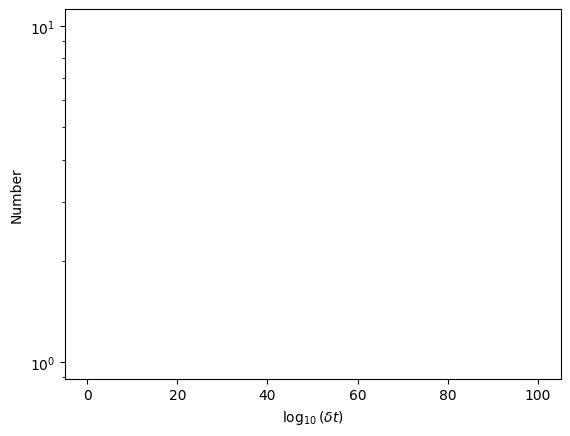

In [25]:
import uproot
import numpy as np

file_path = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/l3_data_run_config_2011_year_2011_0610.root'
with uproot.open(file_path) as f:
    print("File contents:", f.keys())
    event_header = f['I3EventHeader']
    print(event_header.keys())
    event_times = event_header["time_start_mjd"].array(library='np')

bin_edges = np.linspace(0, 100)

dt = event_times[1:] - event_times[:-1]
# Eliminate zeros so we can see the log space
dt = dt[dt != 0]
log_dt = np.log10(dt)
counts, bin_edges = np.histogram(log_dt, bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
fig, ax = plt.subplots()
ax.bar(bin_centers, counts, width=(bin_edges[1] - bin_edges[0]))
ax.set_yscale('log')
plt.ylabel('Number')
plt.xlabel(r'$\log_{10}(\delta t)$')
plt.show()